# Reliability — Consistency (C) metrics

Session-level port of the hal-harness `reliability_eval` **Consistency** metrics to this
output-consistency **replay** experiment (same recorded trace replayed *K=10* times against a
live server). All formulas live in `compare/reliability.py`; this notebook only loads and
visualizes them.

**Unit of analysis.** hal-harness runs an agent *task* K times; here the analog of a task is a
**session** (one recorded trace), and its K "runs" are the K replays. Per session we compute the
metrics across its 10 replays, then compare **across sessions** (Part 1) and **across models** (Part 2).

| Metric | Meaning (1 = perfectly consistent) |
|---|---|
| **C_out** | Outcome consistency — variance of a binary per-run success flag, normalized by `p(1-p)`. *Success is a proxy:* every event `ok` and no `length`-truncation. |
| **C_traj_d** | Trajectory *distribution* — `1 − mean pairwise JSD` of tool-call histograms (successful runs). |
| **C_traj_s** | Trajectory *sequence* — mean pairwise normalized-Levenshtein similarity of tool-call order (successful runs). |
| **C_res** | Resource consistency — `exp(−mean CV)` over cost / time / api_calls / actions / errors / latency. |
| **C_conf** | Confidence consistency — **N/A**: replay carries no model self-reported confidence. |
| **R_con** | Equal-weight aggregate of C_out, mean(C_traj_d, C_traj_s), C_res. |

> **Caveats.** (1) In replay every event is fed the *original recorded input*, so a session
> "trajectory" is a bundle of independent per-event outputs, not a causally chained agent path —
> C_traj measures "same fixed input → same tool structure". (2) With the truncation-based success
> proxy, C_traj is only defined for sessions with ≥2 clean runs, so it can be sparse (esp. for the
> reasoning/`thinking` model, which truncates often). (3) C_out mostly reflects *truncation*
> consistency under this proxy — edit `session_success` in the library to change it.

In [1]:
import sys, math
from pathlib import Path
from dataclasses import asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This notebook lives in experiments/consistency-replay; walk up to find the kit + repo root.
KIT = Path.cwd()
while not (KIT / "compare" / "reliability.py").exists() and KIT != KIT.parent:
    KIT = KIT.parent
sys.path.insert(0, str(KIT))
from compare import compute_consistency  # noqa: E402

REPORTS = KIT.parent.parent / "reports-consistency" / "tau2_airline"

# The three models under comparison. A base dir is one experiment: it holds
# sessions/<session_id>/run_<i>/, the session-major layout every loader here reads.
MODELS = {
    "instruct": REPORTS / "qwen-qwen3-vl-235b-a22b-instruct" / "20260812-session-major",
    "fp8-a100": REPORTS / "qwen-qwen3-5-397b-a17b-fp8-a100" / "20260812-session-major",
    "thinking": REPORTS / "qwen-qwen3-vl-235b-a22b-thinking" / "20260812-session-major",
}

METRICS = ["c_out", "c_traj_d", "c_traj_s", "c_res", "r_con"]  # c_conf omitted (always NaN)
LABELS = {"c_out": "C_out", "c_traj_d": "C_traj_d", "c_traj_s": "C_traj_s",
          "c_res": "C_res", "r_con": "R_con"}

# Okabe–Ito colorblind-safe palette.
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})


def sessions_df(base) -> pd.DataFrame:
    "Per-session metrics for one model as a DataFrame."
    session_metrics, _summary, _skipped = compute_consistency(str(base))
    return pd.DataFrame([asdict(m) for m in session_metrics])


def summary_of(base) -> dict:
    "Library's mean±SE aggregate {metric: {mean, se, n}} for one model."
    _sm, summary, _sk = compute_consistency(str(base))
    return summary

## Part 1 — Single model: consistency across sessions

Compare how consistent the *same model* is from session to session. Change `SINGLE` to inspect
another model.

In [2]:
SINGLE = "instruct"
df1 = sessions_df(MODELS[SINGLE])
df1.set_index("session_id")[["n_runs", "n_success"] + METRICS].rename(columns=LABELS)

,n_runs,n_success,C_out,C_traj_d,C_traj_s,C_res,R_con
session_id,,,,,,,
247b0c0650d3_f6b29499,10,0,1.0,NaN,NaN,0.871933,0.935966
266b7f5a8aa9_0ff1eac5,10,0,1.0,NaN,NaN,0.719215,0.859608
45eff42acfad_3db0b212,10,10,1.0,0.974168,0.944790,0.925331,0.961603
45eff42acfad_5cf9a685,10,9,0.0,1.000000,1.000000,0.845829,0.615276
45eff42acfad_60e35976,10,10,1.0,0.992582,0.937173,0.962287,0.975722
ab2f8ca80599_e217deba,10,0,1.0,NaN,NaN,0.951666,0.975833
d3d3e0d1a8f8_20b42b16,10,0,1.0,NaN,NaN,0.960866,0.980433
d5c4f35bed6a_f98e121b,10,0,1.0,NaN,NaN,0.857026,0.928513
d5c4f35bed6a_fccfdfd8,10,0,1.0,NaN,NaN,0.802405,0.901203


### Descriptive statistics (across sessions)

In [3]:
desc = df1[METRICS].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
desc.rename(index=LABELS).round(3)

,count,mean,std,min,25%,50%,75%,max
C_out,10.0,0.900,0.316,0.000,1.000,1.000,1.000,1.000
C_traj_d,3.0,0.989,0.013,0.974,0.983,0.993,0.996,1.000
C_traj_s,3.0,0.961,0.034,0.937,0.941,0.945,0.972,1.000
C_res,10.0,0.880,0.078,0.719,0.849,0.885,0.945,0.962
R_con,10.0,0.908,0.110,0.615,0.908,0.943,0.972,0.980


### Per-session values (heatmap)

Each row is a session; a `—` means the metric was undefined (e.g. C_traj with <2 clean runs).

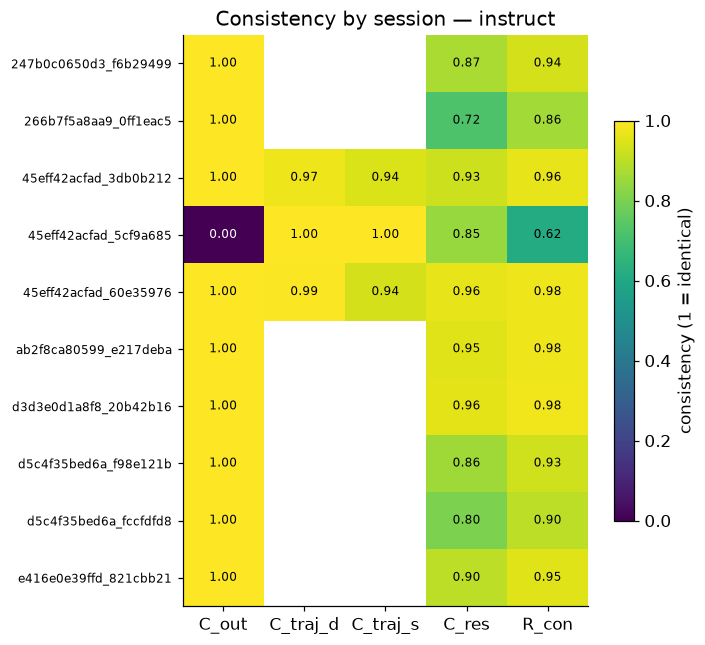

In [4]:
mat = df1.set_index("session_id")[METRICS].rename(columns=LABELS)
fig, ax = plt.subplots(figsize=(6.5, 0.45 * len(mat) + 1.5))
im = ax.imshow(np.ma.masked_invalid(mat.values), aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns)
ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index, fontsize=8)
ax.grid(False)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        txt = "—" if (v is None or (isinstance(v, float) and np.isnan(v))) else f"{v:.2f}"
        col = "white" if (isinstance(v, float) and np.isnan(v)) or v < 0.6 else "black"
        ax.text(j, i, txt, ha="center", va="center", color=col, fontsize=8)
ax.set_title(f"Consistency by session — {SINGLE}")
fig.colorbar(im, ax=ax, shrink=0.7, label="consistency (1 = identical)")
plt.tight_layout(); plt.show()

### Distribution across sessions

Box = IQR, line = median; points are individual sessions.

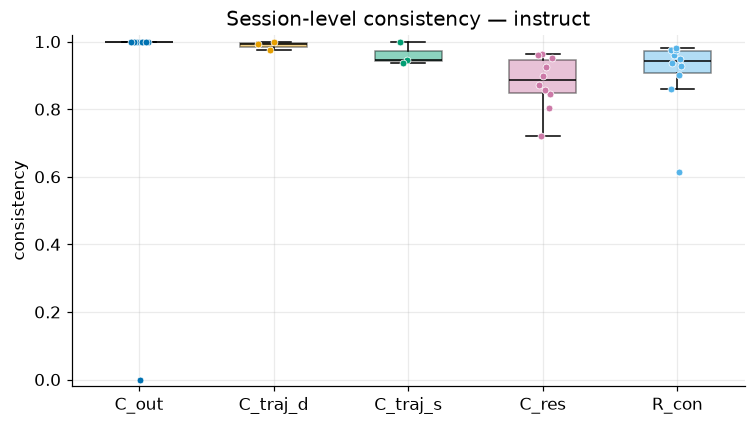

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
data = [df1[m].dropna().values for m in METRICS]
bp = ax.boxplot(data, tick_labels=[LABELS[m] for m in METRICS], showfliers=False,
                patch_artist=True, medianprops=dict(color="black"))
for patch, c in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(c); patch.set_alpha(0.45)
rng = np.random.default_rng(0)
for i, m in enumerate(METRICS, 1):
    y = df1[m].dropna().values
    ax.scatter(rng.normal(i, 0.05, len(y)), y, s=20, color=PALETTE[i - 1],
               edgecolor="white", linewidth=0.5, zorder=3)
ax.set_ylim(-0.02, 1.02); ax.set_ylabel("consistency")
ax.set_title(f"Session-level consistency — {SINGLE}")
plt.tight_layout(); plt.show()

### Which sessions are least consistent overall (R_con)?

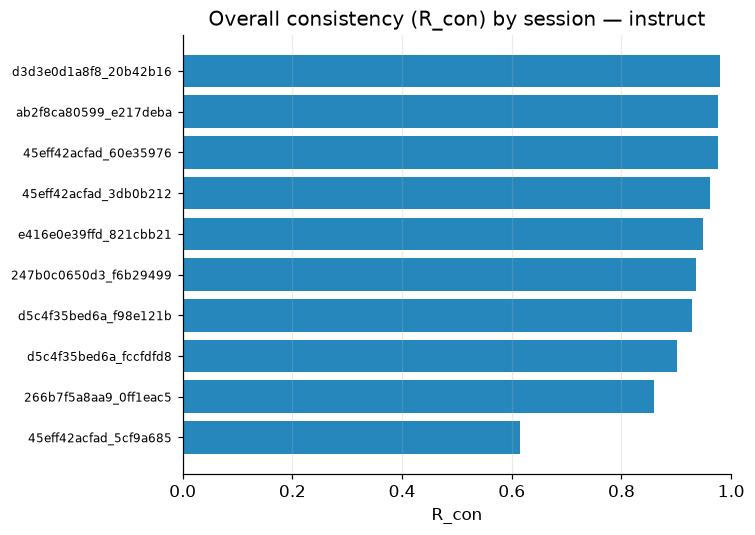

In [6]:
s = df1.set_index("session_id")["r_con"].sort_values()
fig, ax = plt.subplots(figsize=(7, 0.4 * len(s) + 1))
ax.barh(range(len(s)), s.values, color=PALETTE[0], alpha=0.85)
ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index, fontsize=8)
ax.set_xlim(0, 1); ax.set_xlabel("R_con"); ax.grid(axis="y", alpha=0)
ax.set_title(f"Overall consistency (R_con) by session — {SINGLE}")
plt.tight_layout(); plt.show()

## Part 2 — Cross-model comparison

Compare the three models on the same tau2-airline traces. Lower values mean the model's repeated
executions diverge more.

In [7]:
frames = []
for label, base in MODELS.items():
    d = sessions_df(base); d.insert(0, "model", label); frames.append(d)
alldf = pd.concat(frames, ignore_index=True)
print("sessions per model:", alldf.groupby("model").size().to_dict())
alldf.head()

sessions per model: {'fp8-a100': 10, 'instruct': 10, 'thinking': 10}


,model,session_id,n_runs,n_success,c_out,c_traj_d,c_traj_s,c_conf,c_res,r_con
0,instruct,247b0c0650d3_f6b29499,10,0,1.0,NaN,NaN,NaN,0.871933,0.935966
1,instruct,266b7f5a8aa9_0ff1eac5,10,0,1.0,NaN,NaN,NaN,0.719215,0.859608
2,instruct,45eff42acfad_3db0b212,10,10,1.0,0.974168,0.944790,NaN,0.925331,0.961603
3,instruct,45eff42acfad_5cf9a685,10,9,0.0,1.000000,1.000000,NaN,0.845829,0.615276
4,instruct,45eff42acfad_60e35976,10,10,1.0,0.992582,0.937173,NaN,0.962287,0.975722


### Aggregate consistency per model (mean across sessions)

In [8]:
models = list(MODELS)
means = pd.DataFrame(
    {LABELS[m]: {mdl: summary_of(MODELS[mdl])[m]["mean"] for mdl in models} for m in METRICS}
)
means.round(3)

,C_out,C_traj_d,C_traj_s,C_res,R_con
instruct,0.9,0.989,0.961,0.880,0.908
fp8-a100,0.8,0.984,0.918,0.818,0.810
thinking,0.9,NaN,NaN,0.462,0.681


### Mean ± SE by metric and model

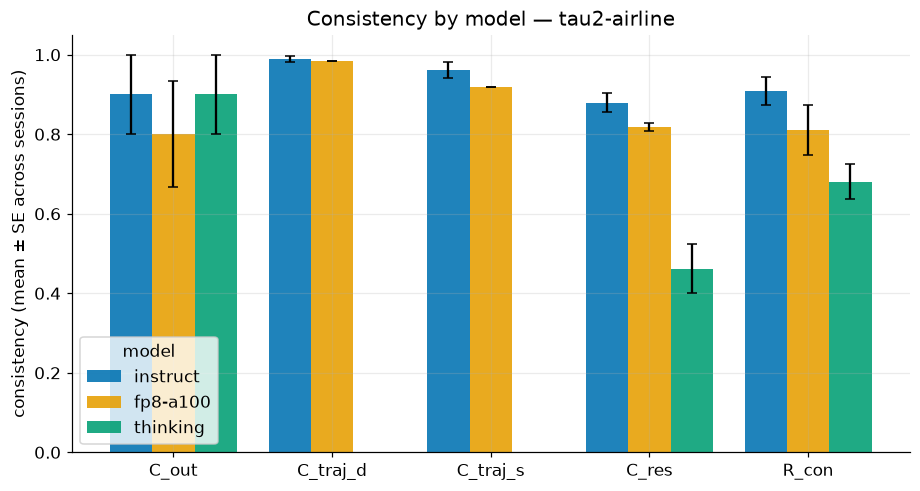

In [9]:
x = np.arange(len(METRICS)); w = 0.8 / len(models)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for k, mdl in enumerate(models):
    summ = summary_of(MODELS[mdl])
    mu = [summ[m]["mean"] if summ[m]["mean"] is not None else np.nan for m in METRICS]
    se = [summ[m]["se"] if summ[m]["se"] is not None else 0 for m in METRICS]
    ax.bar(x + k * w, mu, w, yerr=se, capsize=3, label=mdl, color=PALETTE[k], alpha=0.88)
ax.set_xticks(x + w * (len(models) - 1) / 2)
ax.set_xticklabels([LABELS[m] for m in METRICS])
ax.set_ylim(0, 1.05); ax.set_ylabel("consistency (mean ± SE across sessions)")
ax.set_title("Consistency by model — tau2-airline"); ax.legend(title="model")
plt.tight_layout(); plt.show()

### Session-level distribution by model

How the per-session values spread within each model (overall R_con and resource C_res).

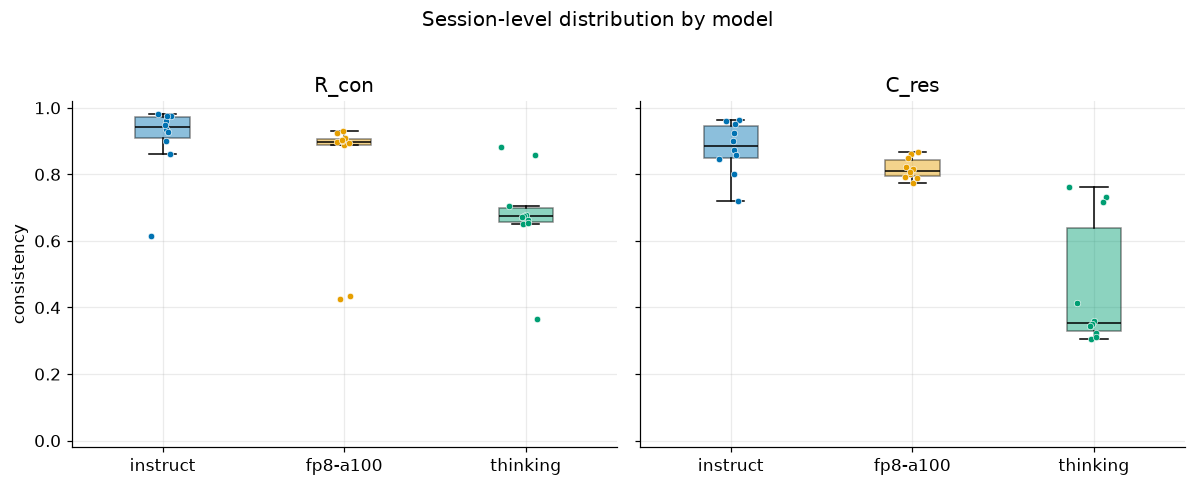

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, metric in zip(axes, ["r_con", "c_res"]):
    data = [alldf[alldf.model == mdl][metric].dropna().values for mdl in models]
    bp = ax.boxplot(data, tick_labels=models, showfliers=False, patch_artist=True,
                    medianprops=dict(color="black"))
    for patch, c in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(c); patch.set_alpha(0.45)
    rng = np.random.default_rng(1)
    for i, mdl in enumerate(models, 1):
        y = alldf[alldf.model == mdl][metric].dropna().values
        ax.scatter(rng.normal(i, 0.05, len(y)), y, s=18, color=PALETTE[i - 1],
                   edgecolor="white", linewidth=0.4, zorder=3)
    ax.set_title(LABELS[metric]); ax.set_ylim(-0.02, 1.02)
axes[0].set_ylabel("consistency")
fig.suptitle("Session-level distribution by model", y=1.02)
plt.tight_layout(); plt.show()

## Part 3 — Per-event consistency across runs

Parts 1–2 take a whole **session** as the unit. This part zooms in to the **event**: one
recorded request (`event_id`), fed *byte-identical* to the server in every one of the K runs.
It is the cleanest consistency question in the experiment — no causal chaining, no session
bundling, just *"the same input K times, how much does the output move?"*

For each event we line up its K replayed responses and score their **agreement across runs**,
delegating every facet to a `compare` primitive (the notebook only aggregates):

| Metric | Meaning (1 = identical across all K runs) |
|---|---|
| **exact-output** | modal share of the K runs producing the *same* full output signature (content **+** canonical tool-args). `n_distinct` counts how many distinct outputs the identical input yielded — **1 = perfectly reproducible**. |
| **content** | mean pairwise content similarity (`fast_content_ratio`), over run-pairs where either side wrote prose. |
| **tool-seq** | mean pairwise tool-name-sequence similarity (`tss`), over pairs where either side called a tool. |
| **tool-args** | mean pairwise argument consistency (`argument_consistency` — Jaccard over `{(tool.key, value)}`), over pairs with any arguments. |

Reported alongside: `fr_agree` (finish-reason agreement) and the resource CVs `tokens_cv` /
`latency_cv` (**lower = steadier**; these measure *spread*, not similarity).

> Pairwise similarities are meant over the **OK** runs only (errored responses drop out of the
> facet means), so each facet reads "when it ran cleanly, how identical was it?" — read it next
> to `n_ok`. `exact-output` / `n_distinct` use the OK signatures; `content` / `tool-seq` /
> `tool-args` are each meant only over the pairs that exercised that channel. The gap between a
> high `content` / `tool-seq` and a low `exact-output` is the tell that the **arguments** move.

In [11]:
# Per-EVENT consistency: one identical recorded input (event_id), replayed K times.
from collections import Counter, defaultdict
from itertools import combinations
from replay_parsing import (iter_sessions, parse_response, collapse_ws, extract_tool_names)
from compare import (response_signature, fast_content_ratio, tss,
                     tool_kv_set, argument_consistency)

# Similarity facets (1 = identical across runs). CV channels are reported separately.
EVENT_SIM = ["exact_agree", "content_sim", "tool_seq_sim", "arg_sim"]
EVENT_LABELS = {"exact_agree": "exact-output", "content_sim": "content",
                "tool_seq_sim": "tool-seq", "arg_sim": "tool-args"}


def _cv(vals):
    "Coefficient of variation over the present values; NaN when undefined."
    a = np.asarray([v for v in vals if v is not None], float)
    if a.size < 2:
        return np.nan
    m = a.mean()
    if m == 0:
        return 0.0 if a.std(ddof=1) == 0 else np.nan
    return float(a.std(ddof=1) / m)


def _latency(r):
    st, et = r["start_time"], r["end_time"]
    return (et - st) if (st is not None and et is not None) else None


def events_df(base) -> pd.DataFrame:
    """One row per event_id: agreement of its K replayed outputs across runs.

    Every metric delegates to a `compare` primitive; this only aggregates. Pairwise
    similarities are meant over the OK runs, channel-aware (a facet is scored only on the
    pairs that exercised it) — the same policy as consistency_statistics.compare_runs.

    Each row is scored inside ONE session (`iter_sessions` hands over a session at a time, and
    `by_event()` is that session's event x run table), so the cross-session step here is just
    concatenating rows — no event is ever compared against another session's runs.
    """
    by_event, sid_of = {}, {}
    for session in iter_sessions(str(base), parse_response):
        for eid, by_run in session.by_event().items():
            by_event[eid] = list(by_run.values())   # this event's K replayed responses
            sid_of[eid] = session.session_id

    mean = lambda xs: float(np.mean(xs)) if xs else np.nan
    rows = []
    for eid, resps in by_event.items():
        n = len(resps)
        ok = [r for r in resps if r["ok"]]
        sigs = [response_signature(r) for r in ok]      # full (content + tool-args) signature
        content, tool_seq, arg = [], [], []
        for a, b in combinations(ok, 2):
            if a["content"].strip() or b["content"].strip():
                content.append(fast_content_ratio(collapse_ws(a["content"]),
                                                   collapse_ws(b["content"])))
            na, nb = extract_tool_names(a["tool_calls"]), extract_tool_names(b["tool_calls"])
            if na or nb:
                tool_seq.append(tss(na, nb))
            ac = argument_consistency(tool_kv_set(a["tool_calls"]), tool_kv_set(b["tool_calls"]))
            if ac is not None:
                arg.append(ac)
        rows.append({
            "event_id": eid, "session_id": sid_of[eid], "n_runs": n, "n_ok": len(ok),
            # headline: modal identical-output share, and how many DISTINCT outputs the
            # identical input produced across runs (1 = perfectly reproducible).
            "exact_agree": (Counter(sigs).most_common(1)[0][1] / n) if sigs else np.nan,
            "n_distinct": len(set(sigs)) if sigs else 0,
            "content_sim": mean(content),
            "tool_seq_sim": mean(tool_seq),
            "arg_sim": mean(arg),
            "fr_agree": Counter(r["finish_reason"] for r in resps).most_common(1)[0][1] / n,
            "tokens_cv": _cv([r["completion_tokens"] for r in ok]),
            "latency_cv": _cv([_latency(r) for r in resps]),
        })
    return pd.DataFrame(rows).sort_values("event_id").reset_index(drop=True)


ev = events_df(MODELS[SINGLE])
print(f"{SINGLE}: {len(ev)} events x {int(ev.n_runs.iloc[0])} runs "
      f"({ev.session_id.nunique()} sessions)")
ev.head(8)

instruct: 89 events x 10 runs (10 sessions)


,event_id,session_id,n_runs,n_ok,exact_agree,n_distinct,content_sim,tool_seq_sim,arg_sim,fr_agree,tokens_cv,latency_cv
0,trace0_d5c4f35bed6a_f98e121b:event_000_155b18b...,d5c4f35bed6a_f98e121b,10,10,0.4,7,0.818740,NaN,NaN,1.0,0.0,0.970074
1,trace0_d5c4f35bed6a_f98e121b:event_001_6c4f31a...,d5c4f35bed6a_f98e121b,10,10,1.0,1,1.000000,NaN,NaN,1.0,0.0,0.025415
2,trace0_d5c4f35bed6a_f98e121b:event_002_18f6c98...,d5c4f35bed6a_f98e121b,10,10,0.4,4,0.840511,NaN,NaN,1.0,0.0,0.073778
3,trace0_d5c4f35bed6a_f98e121b:event_003_14597ef...,d5c4f35bed6a_f98e121b,10,10,0.5,5,0.857019,NaN,NaN,1.0,0.0,0.115249
4,trace0_d5c4f35bed6a_f98e121b:event_004_3a36c93...,d5c4f35bed6a_f98e121b,10,10,0.2,7,0.649477,NaN,NaN,1.0,0.0,0.050696
5,trace0_d5c4f35bed6a_f98e121b:event_005_daeac8e...,d5c4f35bed6a_f98e121b,10,10,0.3,7,0.666180,NaN,NaN,1.0,0.0,0.084288
6,trace0_d5c4f35bed6a_f98e121b:event_006_7211a64...,d5c4f35bed6a_f98e121b,10,10,1.0,1,1.000000,NaN,NaN,1.0,0.0,0.156424
7,trace0_d5c4f35bed6a_f98e121b:event_007_51a8cfd...,d5c4f35bed6a_f98e121b,10,10,0.4,4,0.818145,NaN,NaN,1.0,0.0,0.054366


### Distribution across events

In [12]:
ev[EVENT_SIM + ["fr_agree", "tokens_cv", "latency_cv"]].describe().T[
    ["count", "mean", "std", "min", "50%", "max"]].round(3)

,count,mean,std,min,50%,max
exact_agree,89.0,0.625,0.372,0.100,0.700,1.000
content_sim,38.0,0.852,0.184,0.449,0.954,1.000
tool_seq_sim,53.0,0.986,0.057,0.678,1.000,1.000
arg_sim,53.0,0.580,0.445,0.000,0.800,1.000
fr_agree,89.0,0.999,0.011,0.900,1.000,1.000
tokens_cv,89.0,0.117,0.291,0.000,0.040,2.538
latency_cv,89.0,0.271,0.334,0.025,0.163,2.318


### How reproducible is one identical input?

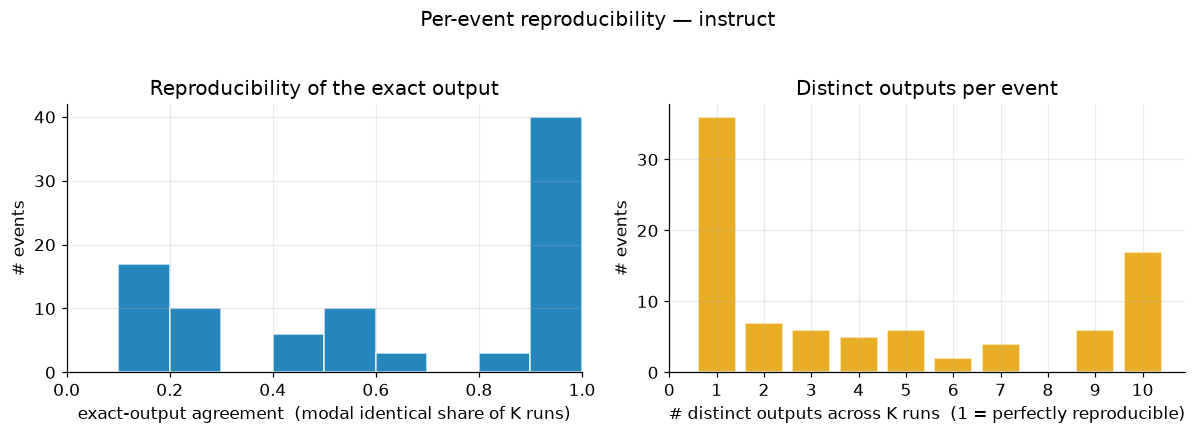

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(ev["exact_agree"].dropna(), bins=np.linspace(0, 1, 11),
             color=PALETTE[0], alpha=0.85, edgecolor="white")
axes[0].set_xlabel("exact-output agreement  (modal identical share of K runs)")
axes[0].set_ylabel("# events"); axes[0].set_xlim(0, 1)
axes[0].set_title("Reproducibility of the exact output")
vc = ev["n_distinct"].value_counts().sort_index()
axes[1].bar(vc.index, vc.values, color=PALETTE[1], alpha=0.85, edgecolor="white")
axes[1].set_xlabel("# distinct outputs across K runs  (1 = perfectly reproducible)")
axes[1].set_ylabel("# events")
axes[1].set_xticks(range(0, int(ev["n_distinct"].max()) + 1))
axes[1].set_title("Distinct outputs per event")
fig.suptitle(f"Per-event reproducibility — {SINGLE}", y=1.03)
plt.tight_layout(); plt.show()

### Per-event agreement by facet

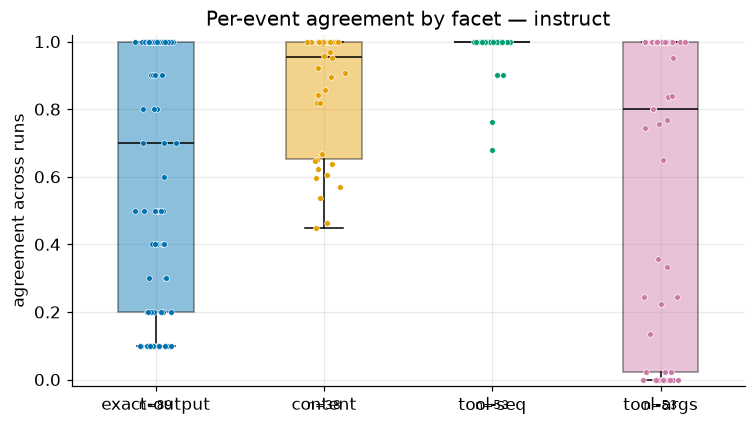

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
data = [ev[m].dropna().values for m in EVENT_SIM]
bp = ax.boxplot(data, tick_labels=[EVENT_LABELS[m] for m in EVENT_SIM], showfliers=False,
                patch_artist=True, medianprops=dict(color="black"))
for patch, c in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(c); patch.set_alpha(0.45)
rng = np.random.default_rng(2)
for i, m in enumerate(EVENT_SIM, 1):
    y = ev[m].dropna().values
    ax.scatter(rng.normal(i, 0.05, len(y)), y, s=14, color=PALETTE[i - 1],
               edgecolor="white", linewidth=0.4, zorder=3)
    ax.annotate(f"n={len(y)}", (i, -0.06), ha="center", va="top", fontsize=8, annotation_clip=False)
ax.set_ylim(-0.02, 1.02); ax.set_ylabel("agreement across runs")
ax.set_title(f"Per-event agreement by facet — {SINGLE}")
plt.tight_layout(); plt.show()

### Least reproducible events (drill-down)

The events where an identical input produced the most varied output. When `content` / `tool-seq`
sit near 1.0 but `exact-output` is low, the model kept the same words and the same tool *names*
across runs and only the **argument values** moved — `tool-args` (and `n_distinct`) locate it.

In [15]:
cols = ["session_id", "n_ok", "n_distinct", "exact_agree", "content_sim",
        "tool_seq_sim", "arg_sim"]
ev.sort_values(["exact_agree", "content_sim"]).head(10).set_index("event_id")[cols].round(3)

,session_id,n_ok,n_distinct,exact_agree,content_sim,tool_seq_sim,arg_sim
event_id,,,,,,,
trace4_247b0c0650d3_f6b29499:event_002_5ae9d12858b7775c,247b0c0650d3_f6b29499,10,10,0.1,0.449,NaN,NaN
trace4_247b0c0650d3_f6b29499:event_003_f8ec78c955ffc388,247b0c0650d3_f6b29499,10,10,0.1,0.464,NaN,NaN
trace4_247b0c0650d3_f6b29499:event_001_cb5a202caa7c05e6,247b0c0650d3_f6b29499,10,10,0.1,0.637,NaN,NaN
trace4_247b0c0650d3_f6b29499:event_000_c5a77c5d2893c728,247b0c0650d3_f6b29499,10,10,0.1,0.645,NaN,NaN
trace1_45eff42acfad_60e35976:event_014_32c2291b2c1996d2,45eff42acfad_60e35976,10,10,0.1,1.000,1.0,0.0
trace1_45eff42acfad_60e35976:event_003_23eda1ab9e0be088,45eff42acfad_60e35976,10,10,0.1,NaN,1.0,0.0
trace1_45eff42acfad_60e35976:event_007_f49f7283579517f9,45eff42acfad_60e35976,10,10,0.1,NaN,1.0,0.0
trace1_45eff42acfad_60e35976:event_008_635ad040f361975a,45eff42acfad_60e35976,10,10,0.1,NaN,1.0,0.0
trace1_45eff42acfad_60e35976:event_009_3282c4aec9da01d5,45eff42acfad_60e35976,10,10,0.1,NaN,1.0,0.0


### Cross-model comparison (per event)

In [16]:
ev_by_model = {mdl: events_df(base) for mdl, base in MODELS.items()}
tbl = pd.DataFrame({
    mdl: {"n_events": len(d), "frac_reproducible": (d["n_distinct"] == 1).mean(),
          **{EVENT_LABELS[m]: d[m].mean() for m in EVENT_SIM}}
    for mdl, d in ev_by_model.items()
}).T
tbl.round(3)

,n_events,frac_reproducible,exact-output,content,tool-seq,tool-args
instruct,89.0,0.404,0.625,0.852,0.986,0.580
fp8-a100,89.0,0.472,0.663,0.912,0.938,0.496
thinking,89.0,0.022,0.353,0.595,0.925,0.319


### Permutation baseline (model-blind)

How much of a model's per-event consistency is *real*, versus what any random mix of these
outputs would already show? For each event we **pool all runs across the three models** (~30) and
repeatedly draw `K=10` at random — **ignoring which model produced each run** — then recompute the
same facets and average over the draws. That model-blind draw is the grey **baseline** bar in the
next chart.

A model bar clearly **above** the baseline means its repeated runs agree *more* than a random
shuffle of comparable outputs — genuine within-model reproducibility. A bar **at or below** the
baseline means the model is no more self-consistent than the mixed pool. `tool-seq` sits high even
for the baseline because the tau2-airline tool structure is constrained (the same few tools in a
similar order regardless of model), so there is little headroom there.

Each bar is annotated `n=…`, the number of events its mean was computed over (a facet is defined
only on events that exercised that channel, so `content` / `tool-args` cover fewer events). The
draws are seeded (`np.random.default_rng(41)`), so the baseline is reproducible *for a given pool
order*. It is only the **draws** that are order-sensitive, not the data: moving to the
session-major layout left every event's pooled multiset of responses identical but reordered them
(runs now sort numerically, and events arrive grouped by session), which shifts the seeded means
by ~0.002 — Monte-Carlo noise, not a change in what is measured.

In [17]:
# Permutation baseline (model-blind): if we IGNORE which model produced each run, how consistent
# would an event's K outputs look? For each event we pool all runs across the three models (~30),
# repeatedly draw K=10 at random, recompute the same facets, and average over the draws. A model
# bar standing above this baseline means its repeats agree MORE than a random mix of comparable
# outputs would — genuine within-model consistency. Same facet definitions as events_df.
N_PERM = 200      # random K-draws per event
K_DRAW = 10       # runs per draw (matches the per-model run count)
PERM_SEED = 41


def _load_pool(models):
    """event_id -> parsed responses pooled across ALL models (model identity discarded).

    Pooling is the point here — the baseline needs a mixed bag. It still pools per EVENT, and an
    event_id is a property of the recorded trace, so the same event is the same recorded input in
    every model's experiment: `pool[eid]` holds ~3 x K responses to one identical request.
    """
    pool = defaultdict(list)
    for base in models.values():
        for session in iter_sessions(str(base), parse_response):
            for eid, by_run in session.by_event().items():
                pool[eid].extend(by_run.values())
    return pool


def _precompute_pairs(resps):
    "Cache each ok-ok pair's facet value ONCE, so every draw is a lookup, not a recompute."
    ok = [r["ok"] for r in resps]
    sig = [response_signature(r) if r["ok"] else None for r in resps]
    cc = [collapse_ws(r["content"]) for r in resps]
    nm = [extract_tool_names(r["tool_calls"]) for r in resps]
    kv = [tool_kv_set(r["tool_calls"]) for r in resps]
    cpair, tpair, apair = {}, {}, {}
    n = len(resps)
    for i in range(n):
        if not ok[i]:
            continue
        for j in range(i + 1, n):
            if not ok[j]:
                continue
            if cc[i] or cc[j]:
                cpair[(i, j)] = fast_content_ratio(cc[i], cc[j])
            if nm[i] or nm[j]:
                tpair[(i, j)] = tss(nm[i], nm[j])
            ac = argument_consistency(kv[i], kv[j])
            if ac is not None:
                apair[(i, j)] = ac
    return ok, sig, cpair, tpair, apair


def baseline_df(models, k=K_DRAW, n_perm=N_PERM, seed=PERM_SEED) -> pd.DataFrame:
    "Per-event model-blind baseline: mean over n_perm random K-draws from the pooled runs."
    pool = _load_pool(models)
    rng = np.random.default_rng(seed)
    rows = []
    for eid, resps in pool.items():
        n = len(resps)
        if n < k:
            continue

        ok, sig, cpair, tpair, apair = _precompute_pairs(resps)

        def mp(cache, idxs):  # mean over the sampled ok-pairs that exercised this channel
            vals = [cache[(a, b)] for a, b in combinations(idxs, 2) if (a, b) in cache]
            return float(np.mean(vals)) if vals else np.nan

        acc = defaultdict(list)
        for _ in range(n_perm):
            idxs = sorted(int(i) for i in rng.choice(n, k, replace=False))
            oki = [i for i in idxs if ok[i]]
            sigs = [sig[i] for i in oki]
            draw = {
                "exact_agree": (Counter(sigs).most_common(1)[0][1] / k) if sigs else np.nan,
                "content_sim": mp(cpair, oki),
                "tool_seq_sim": mp(tpair, oki),
                "arg_sim": mp(apair, oki),
            }
            for key, v in draw.items():
                if not (isinstance(v, float) and np.isnan(v)):
                    acc[key].append(v)
        rows.append({"event_id": eid,
                     **{m: (float(np.mean(acc[m])) if acc[m] else np.nan) for m in EVENT_SIM}})
    return pd.DataFrame(rows)


baseline = baseline_df(MODELS)  # ~20s: the one-time pair cache dominates; the draws are cheap
print(f"model-blind baseline: {len(baseline)} events, {N_PERM} draws of K={K_DRAW} "
      f"from ~{3 * K_DRAW} pooled runs/event")
baseline[EVENT_SIM].describe().T[["count", "mean", "std", "min", "50%", "max"]].round(3)

model-blind baseline: 89 events, 200 draws of K=10 from ~30 pooled runs/event


,count,mean,std,min,50%,max
exact_agree,89.0,0.437,0.295,0.100,0.362,1.000
content_sim,38.0,0.410,0.066,0.216,0.419,0.573
tool_seq_sim,54.0,0.916,0.238,0.000,1.000,1.000
arg_sim,53.0,0.419,0.381,0.000,0.433,1.000


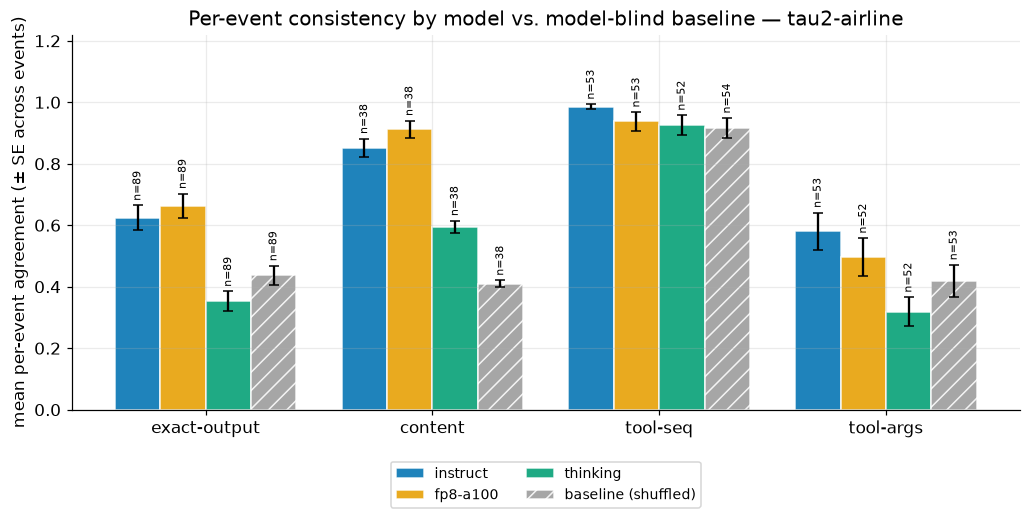

In [18]:
# Per-event consistency by model, with the model-blind permutation baseline (grey, hatched).
# Each bar is labelled n = the number of events its mean covers (a facet is defined only where
# it was exercised, so content / tool-args span fewer events than exact-output).
series = [(mdl, ev_by_model[mdl], PALETTE[i]) for i, mdl in enumerate(MODELS)]
series.append(("baseline (shuffled)", baseline, "#9a9a9a"))

x = np.arange(len(EVENT_SIM)); w = 0.8 / len(series)
fig, ax = plt.subplots(figsize=(9.5, 4.9))
for k, (label, d, color) in enumerate(series):
    mu, se, ns = [], [], []
    for m in EVENT_SIM:
        v = d[m].dropna()
        ns.append(len(v))
        mu.append(v.mean() if len(v) else np.nan)
        se.append(v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0)
    xpos = x + k * w
    is_base = label.startswith("baseline")
    ax.bar(xpos, mu, w, yerr=se, capsize=3, label=label, color=color, alpha=0.88,
           hatch="//" if is_base else None, edgecolor="white")
    for xi, m_, s_, n_ in zip(xpos, mu, se, ns):
        if not np.isnan(m_):
            ax.annotate(f"n={n_}", (xi, m_ + s_ + 0.015), ha="center", va="bottom",
                        fontsize=7, rotation=90)
ax.set_xticks(x + w * (len(series) - 1) / 2)
ax.set_xticklabels([EVENT_LABELS[m] for m in EVENT_SIM])
ax.set_ylim(0, 1.22); ax.set_ylabel("mean per-event agreement (± SE across events)")
ax.set_title("Per-event consistency by model vs. model-blind baseline — tau2-airline")
ax.legend(ncol=2, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout(); plt.show()

### Takeaways

Read the bars/boxes together with the coverage counts (`n`) — a high C_traj on a model that only had
a couple of clean sessions is thin evidence. Points to check when interpreting:

- **C_res** is the most comparable metric across models (defined for every session, no success gate).
- **C_traj_d / C_traj_s** coverage depends on how many sessions completed cleanly under the success
  proxy; the `thinking` model may have few or none.
- **C_conf** is intentionally absent (no confidence signal in tau2 replay data).
- **Part 3 (per-event)** is the finest scope: the same fixed input replayed K times. Watch the gap
  between `exact-output` and `content` / `tool-seq` — when the prose and tool names reproduce but the
  exact output does not, the variation lives in the **arguments** (`tool-args`, `n_distinct`).
- **Model-blind baseline (per-event bar chart).** Compare each model's bar against the grey
  baseline — a random `K`-of-~30 draw that ignores model identity. `instruct` / `fp8-a100` sit
  clearly above it on `exact-output` and `content`, so their reproducibility is real, not an
  artifact of the pooled output distribution; `thinking` falls to/below the baseline, meaning it is
  no more self-consistent than a random mix. `tool-seq` has little headroom over the baseline for
  anyone — the airline tool structure is constrained regardless of model.

To change the outcome definition (and thus C_out and C_traj coverage), edit `session_success` in
`compare/reliability.py` — every caller, including this notebook, picks up the change.